베터리에 큰 영향을 주는 요인을 주는 요인 찾기


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import platform
import ast

df1= pd.read_csv("metadata.csv")

In [2]:
df = df1.copy()

In [3]:
plt.rcParams['font.family'] = 'Malgun Gothic' # For Windows 
%matplotlib inline

df = pd.read_csv("metadata.csv", encoding='utf-8')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   type                 7565 non-null   str  
 1   start_time           7565 non-null   str  
 2   ambient_temperature  7565 non-null   int64
 3   battery_id           7565 non-null   str  
 4   test_id              7565 non-null   int64
 5   uid                  7565 non-null   int64
 6   filename             7565 non-null   str  
 7   Capacity             2794 non-null   str  
 8   Re                   1956 non-null   str  
 9   Rct                  1956 non-null   str  
dtypes: int64(3), str(7)
memory usage: 591.1 KB


In [5]:
import pandas as pd

def check_missing(df, top_n=None):
    missing_df = pd.DataFrame({
        'missing_count': df.isna().sum(),
        'missing_ratio': df.isna().mean()*100
    }).sort_values('missing_count', ascending=False)
    
    if top_n:
        return missing_df.head(top_n)
    
    return missing_df


In [6]:
check_missing(df)

,missing_count,missing_ratio
Rct,5609,74.144085
Re,5609,74.144085
Capacity,4771,63.066755
type,0,0.000000
start_time,0,0.000000
ambient_temperature,0,0.000000
uid,0,0.000000
test_id,0,0.000000
battery_id,0,0.000000
filename,0,0.000000


Re(전해질 저항(Ω)) 결축 5609개 ,
Rct(충전 전달 저항(Ω)) 결축 5609개,
Capacity(배터리 현재 용량(Ah)) 결측 4771개

Re , Rct, Capacity = 내용은 숫자인데 타입은 문자형으로 찍힘

start_time(테스트 시작 시간) datetime으로 변환 필요

test_id(실험 ID) 는 0 ~615 

In [7]:
df['battery_id'].value_counts().sum()

np.int64(7565)

In [8]:
df['Capacity'] = pd.to_numeric(df['Capacity'], errors='coerce')
df['Re'] = pd.to_numeric(df['Re'], errors='coerce')
df['Rct'] = pd.to_numeric(df['Rct'], errors='coerce')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 7565 non-null   str    
 1   start_time           7565 non-null   str    
 2   ambient_temperature  7565 non-null   int64  
 3   battery_id           7565 non-null   str    
 4   test_id              7565 non-null   int64  
 5   uid                  7565 non-null   int64  
 6   filename             7565 non-null   str    
 7   Capacity             2769 non-null   float64
 8   Re                   1947 non-null   float64
 9   Rct                  1947 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 591.1 KB


형테 이상해서 pd.to_datetime 안됨
리스트 분해해서 형태 재정비부터


In [10]:
df['start_time']

0       [2010.       7.      21.      15.       0.    ...
1       [2010.       7.      21.      16.      53.    ...
2       [2010.       7.      21.      17.      25.    ...
3                         [2010    7   21   20   31    5]
4       [2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...
                              ...                        
7560    [2010.       9.      30.       7.      36.    ...
7561    [2010.       9.      30.       8.       8.    ...
7562    [2010.      9.     30.      8.     48.     54.25]
7563    [2010.       9.      30.      11.      50.    ...
7564    [2010.       9.      30.      12.      31.    ...
Name: start_time, Length: 7565, dtype: str

In [11]:
def clear_time(x):
    #사용할 리스트
    nums = []
    #임시 저장용
    current = ''
    
# 반복문으로 숫자만 뽑아내기
    for ch in x:
        #숫자형이거나 형태 다른 숫자 뽑아내기
        if ch.isdigit() or ch in ['.','_','e','E','+']:
            current += ch
        else:
            if current != '' :
                nums.append(current)
                current = ''
            
    #숫자 남아있을 수도 있으니 한번더 이스트에 append
    if current != '':
        nums.append(current)
    
    #연월일시분초 하면 최소 6자리, 그 이하는 버림
    if len(nums) <6 :
        return None
    
    #num리스트 숫자형으로 변환, 연월일시분초 하면 6개임으로 앞에 6개만 숫자변환
    try :
        nums = list(map(float, nums[:6]))
    except:
        return None
    
    #각 숫자에 의미부여
    year, month, day, hour, minute, second = nums
    
    # 이상치 제거, 연월일시분초 중에 값이 이상하게 들어갔을 수도 있어서 제한 걸기
    if not (2000< year and 1 <= month <= 12 and 1 <= day <= 31 and 
            0 <= hour < 24 and 0 <= minute < 60 and 0 <= second < 60):
        return None
    
    #Timestamp 로 date_time 변환
    return pd.Timestamp(
        int(year), int(month), int(day),
        int(hour), int(minute), int(second)
    )

df['start_time'] = df['start_time'].apply(clear_time)
df = df.dropna(subset=['start_time'])

In [12]:
df['start_time']

0      2010-07-21 15:00:35
1      2010-07-21 16:53:45
2      2010-07-21 17:25:40
3      2010-07-21 20:31:05
4      2010-07-21 21:02:56
               ...        
7560   2010-09-30 07:36:45
7561   2010-09-30 08:08:36
7562   2010-09-30 08:48:54
7563   2010-09-30 11:50:17
7564   2010-09-30 12:31:10
Name: start_time, Length: 7412, dtype: datetime64[us]

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 7412 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   type                 7412 non-null   str           
 1   start_time           7412 non-null   datetime64[us]
 2   ambient_temperature  7412 non-null   int64         
 3   battery_id           7412 non-null   str           
 4   test_id              7412 non-null   int64         
 5   uid                  7412 non-null   int64         
 6   filename             7412 non-null   str           
 7   Capacity             2720 non-null   float64       
 8   Re                   1902 non-null   float64       
 9   Rct                  1902 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(3), str(3)
memory usage: 637.0 KB


- 결측 없던 행들에서 153개행씩 없어짐
- Capacity 49 개행 없어짐
- Re, Rct에서 45개행 없어짐

In [14]:
#베터리 종류 34개
df['battery_id'].value_counts().index

Index(['B0006', 'B0005', 'B0007', 'B0034', 'B0033', 'B0036', 'B0018', 'B0043',
       'B0042', 'B0044', 'B0054', 'B0056', 'B0055', 'B0047', 'B0045', 'B0048',
       'B0046', 'B0041', 'B0053', 'B0039', 'B0040', 'B0038', 'B0032', 'B0029',
       'B0030', 'B0031', 'B0028', 'B0027', 'B0025', 'B0026', 'B0049', 'B0050',
       'B0052', 'B0051'],
      dtype='str', name='battery_id')

In [15]:
df['battery_id'].nunique()

34

데이터 파일 하나로 묶고 표시하기

In [16]:
import pandas as pd
import os

df_list = []

for i in range(1, 7566):
    file_name = str(i).zfill(5) + '.csv'   # 00001.csv
    
    file_path = os.path.join('data1', file_name)
    
    if os.path.exists(file_path):  # 파일 존재 확인
        temp = pd.read_csv(file_path)
        
        temp['file_name'] = file_name  # 출처 표시
        
        df_list.append(temp)

file_df = pd.concat(df_list, ignore_index=True)

In [17]:
file_df

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time,file_name,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance,Current_charge,Voltage_charge
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000,00001.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360,00001.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281,00001.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406,00001.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625,00001.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376829,4.214016,0.034080,6.398011,NaN,NaN,10777.672,07565.csv,NaN,NaN,NaN,NaN,NaN,0.0348,4.25
7376830,4.213823,0.034787,6.412317,NaN,NaN,10784.047,07565.csv,NaN,NaN,NaN,NaN,NaN,0.0348,4.25
7376831,4.214100,0.034863,6.407888,NaN,NaN,10790.547,07565.csv,NaN,NaN,NaN,NaN,NaN,0.0348,4.25
7376832,4.213995,0.032502,6.417216,NaN,NaN,10796.969,07565.csv,NaN,NaN,NaN,NaN,NaN,0.0348,4.25


In [18]:
file_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7376834 entries, 0 to 7376833
Data columns (total 14 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Voltage_measured      float64
 1   Current_measured      float64
 2   Temperature_measured  float64
 3   Current_load          float64
 4   Voltage_load          float64
 5   Time                  float64
 6   file_name             str    
 7   Sense_current         str    
 8   Battery_current       str    
 9   Current_ratio         str    
 10  Battery_impedance     str    
 11  Rectified_Impedance   str    
 12  Current_charge        float64
 13  Voltage_charge        float64
dtypes: float64(8), str(6)
memory usage: 787.9 MB


In [19]:
check_missing(file_df)

,missing_count,missing_ratio
Rectified_Impedance,7300550,98.965898
Sense_current,7282946,98.727259
Battery_current,7282946,98.727259
Current_ratio,7282946,98.727259
Battery_impedance,7282946,98.727259
Voltage_load,6606764,89.560969
Current_load,6606764,89.560969
Current_charge,863958,11.711772
Voltage_charge,863958,11.711772
Current_measured,94145,1.276225


정렬후 사이클칼럼 추가

In [20]:
df['cycle'] = df.groupby('battery_id').cumcount()

타입별로 분리

In [21]:
discharge_df = df[df['type']=='discharge'].copy()
impedance_df = df[df['type']=='impedance'].copy()
charge_df = df[df['type']=='charge'].copy()

soh 구하기 : 현재 배터리 용량 / 처음 배터리 용량

In [22]:
#discharge_df 를 베터리 아이디별 시간순으로 정렬
discharge_df = discharge_df.sort_values(['battery_id', 'start_time'])

In [23]:
#Capacity 혹시 모르니 숫자형으로 다시변환, 
discharge_df['Capacity'] = pd.to_numeric(discharge_df['Capacity'], errors='coerce')
#Capacity 값이 없는 행 제거
discharge_df = discharge_df.dropna(subset=['Capacity'])

In [24]:
#Capacity 는 실험을 진행 할 수록 값이 작아지므로 제일 큰게 제일 초기값이라 가정
#
initial_capacity = discharge_df.groupby('battery_id')['Capacity'].transform('max')

discharge_df['SOH'] = discharge_df['Capacity'] / initial_capacity

In [25]:
#soh는 배터리당 현재 capacity에서  가장큰  capacity를 나누는 것이기에 1 이하 값이여야함
discharge_df['SOH']

5121    1.000000
5123    0.994527
5125    0.988614
5127    0.988567
5129    0.988235
          ...   
7299    0.858337
7301    0.840714
7305    0.850230
7309    0.845962
7311    0.839851
Name: SOH, Length: 2720, dtype: float64

In [26]:
discharge_df.groupby('battery_id')['Capacity'].max()

battery_id
B0005    1.856487
B0006    2.035338
B0007    1.891052
B0018    1.855005
B0025    1.848984
B0026    1.816528
B0027    1.823308
B0028    1.804783
B0029    1.844701
B0030    1.781555
B0031    1.832858
B0032    1.894032
B0033    1.885140
B0034    1.820306
B0036    1.985493
B0038    1.786441
B0039    1.771573
B0040    1.734130
B0041    1.215649
B0042    1.731471
B0043    1.713783
B0044    1.686526
B0045    1.081979
B0046    1.728239
B0047    1.674305
B0048    1.657996
B0049    2.378644
B0050    2.640149
B0051    2.330873
B0052    1.418310
B0053    1.154073
B0054    1.166544
B0055    1.319892
B0056    1.344356
Name: Capacity, dtype: float64

배터리 이름별 시간순 정렬

------

eda

In [27]:
#타입별 분포
df['type'].value_counts()

type
charge       2757
discharge    2745
impedance    1910
Name: count, dtype: int64

In [28]:
#베터리 종류 34개
df['battery_id'].value_counts().index

Index(['B0006', 'B0005', 'B0007', 'B0034', 'B0033', 'B0036', 'B0018', 'B0043',
       'B0042', 'B0044', 'B0054', 'B0056', 'B0055', 'B0047', 'B0045', 'B0048',
       'B0046', 'B0041', 'B0053', 'B0039', 'B0040', 'B0038', 'B0032', 'B0029',
       'B0030', 'B0031', 'B0028', 'B0027', 'B0025', 'B0026', 'B0049', 'B0050',
       'B0052', 'B0051'],
      dtype='str', name='battery_id')

In [29]:
df.describe()

,start_time,ambient_temperature,test_id,uid,Capacity,Re,Rct,cycle
count,7412,7412.000000,7412.000000,7412.000000,2720.000000,1.902000e+03,1.902000e+03,7412.000000
mean,2009-08-13 04:43:16.719239,20.008635,176.781031,3781.983270,1.324264,-5.094240e+11,1.080885e+12,173.112520
min,2008-04-02 13:08:17,4.000000,0.000000,1.000000,0.000000,-9.689245e+14,-2.091081e+02,0.000000
25%,2008-07-10 21:17:26.500000,4.000000,55.000000,1891.750000,1.150253,5.782048e-02,8.151586e-02,54.000000
50%,2009-08-02 06:08:41,24.000000,130.000000,3786.500000,1.426172,7.250748e-02,1.009107e-01,127.000000
75%,2010-06-30 09:43:01.750000,24.000000,257.000000,5671.250000,1.671568,9.213421e-02,1.556645e-01,251.000000
max,2010-09-30 15:32:33,44.000000,615.000000,7565.000000,2.640149,4.482291e+02,2.055843e+15,606.000000
std,NaN,11.112114,152.744871,2183.402825,0.473419,2.221696e+13,4.713948e+13,150.019628


-----

## capacity 분포 확인

capacity 가 결측이 아닌게 어딘지 확인

In [30]:
df[df['Capacity'].notna()]

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,cycle
0,discharge,2010-07-21 15:00:35,4,B0047,0,1,00001.csv,1.674305,NaN,NaN,0
4,discharge,2010-07-21 21:02:56,4,B0047,4,5,00005.csv,1.524366,NaN,NaN,4
6,discharge,2010-07-22 01:40:06,4,B0047,6,7,00007.csv,1.508076,NaN,NaN,6
8,discharge,2010-07-22 06:16:21,4,B0047,8,9,00009.csv,1.483558,NaN,NaN,8
10,discharge,2010-07-22 10:51:48,4,B0047,10,11,00011.csv,1.467139,NaN,NaN,10
...,...,...,...,...,...,...,...,...,...,...,...
7551,discharge,2010-09-29 16:08:13,4,B0055,238,7552,07552.csv,1.003655,NaN,NaN,232
7553,discharge,2010-09-29 19:50:59,4,B0055,240,7554,07554.csv,1.028527,NaN,NaN,234
7557,discharge,2010-09-30 03:15:20,4,B0055,244,7558,07558.csv,1.012712,NaN,NaN,237
7561,discharge,2010-09-30 08:08:36,4,B0055,248,7562,07562.csv,1.020138,NaN,NaN,241


전부 discharge

- discharge에서 분포확인

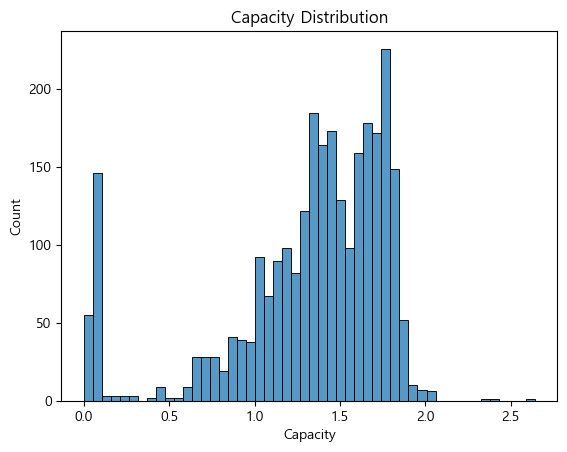

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(discharge_df['Capacity'], bins=50)
plt.title('Capacity Distribution')
plt.show()

측정전압 분포확인

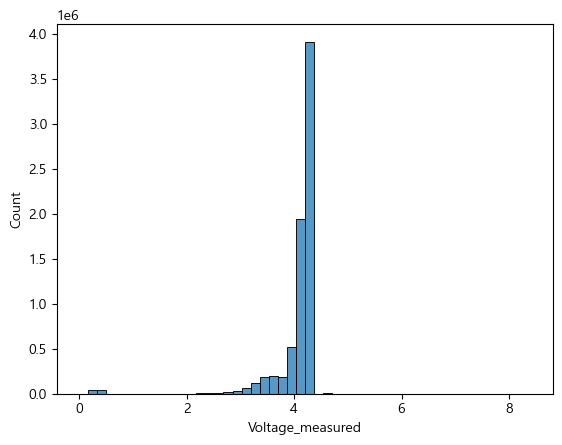

In [32]:
sns.histplot(file_df['Voltage_measured'], bins=50)
plt.show()

------------


In [33]:
discharge_df

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,cycle,SOH
5121,discharge,2008-04-02 15:25:41,24,B0005,1,5122,05122.csv,1.856487,NaN,NaN,1,1.000000
5123,discharge,2008-04-02 19:43:48,24,B0005,3,5124,05124.csv,1.846327,NaN,NaN,3,0.994527
5125,discharge,2008-04-03 00:01:06,24,B0005,5,5126,05126.csv,1.835349,NaN,NaN,5,0.988614
5127,discharge,2008-04-03 04:16:37,24,B0005,7,5128,05128.csv,1.835263,NaN,NaN,7,0.988567
5129,discharge,2008-04-03 08:33:25,24,B0005,9,5130,05130.csv,1.834646,NaN,NaN,9,0.988235
...,...,...,...,...,...,...,...,...,...,...,...,...
7299,discharge,2010-09-29 16:08:13,4,B0056,238,7300,07300.csv,1.153909,NaN,NaN,232,0.858337
7301,discharge,2010-09-29 19:50:59,4,B0056,240,7302,07302.csv,1.130219,NaN,NaN,234,0.840714
7305,discharge,2010-09-30 03:15:20,4,B0056,244,7306,07306.csv,1.143011,NaN,NaN,237,0.850230
7309,discharge,2010-09-30 08:08:36,4,B0056,248,7310,07310.csv,1.137273,NaN,NaN,241,0.845962


## 분석시작

In [34]:
df['type'].value_counts()

type
charge       2757
discharge    2745
impedance    1910
Name: count, dtype: int64

In [35]:
battery_list = df['battery_id'].unique()
print(battery_list)

print("총 배터리 수:", df['battery_id'].nunique())

<StringArray>
['B0047', 'B0045', 'B0048', 'B0046', 'B0043', 'B0032', 'B0039', 'B0040',
 'B0029', 'B0028', 'B0042', 'B0034', 'B0038', 'B0033', 'B0030', 'B0041',
 'B0027', 'B0044', 'B0036', 'B0025', 'B0026', 'B0031', 'B0049', 'B0050',
 'B0052', 'B0051', 'B0006', 'B0005', 'B0007', 'B0018', 'B0053', 'B0054',
 'B0056', 'B0055']
Length: 34, dtype: str
총 배터리 수: 34


In [36]:
df['ambient_temperature'].value_counts()

ambient_temperature
24    4554
4     2027
43     384
22     240
44     207
Name: count, dtype: int64

In [37]:
df.groupby('type').agg({
    'Capacity': lambda x: x.notna().sum(),
    'Re': lambda x: x.notna().sum(),
    'Rct': lambda x: x.notna().sum()
})

,Capacity,Re,Rct
type,,,
charge,0,0,0
discharge,2720,0,0
impedance,0,1902,1902


In [38]:
summary_df = df.groupby('battery_id').agg(
    min_cap = ('Capacity', 'min'),
    max_cap = ('Capacity', 'max'),
    n_cycles = ('Capacity', 'count')
).reset_index()

print(summary_df)

   battery_id   min_cap   max_cap  n_cycles
0       B0005  1.287453  1.856487       166
1       B0006  1.153818  2.035338       166
2       B0007  1.400455  1.891052       166
3       B0018  1.341051  1.855005       129
4       B0025  1.767789  1.848984        27
5       B0026  1.386337  1.816528        27
6       B0027  1.770093  1.823308        27
7       B0028  1.717234  1.804783        27
8       B0029  1.612080  1.844701        39
9       B0030  1.562780  1.781555        39
10      B0031  1.666675  1.832858        39
11      B0032  1.635800  1.894032        39
12      B0033  0.068426  1.885140       193
13      B0034  0.745930  1.820306       193
14      B0036  1.001983  1.985493       193
15      B0038  0.898057  1.786441        45
16      B0039  0.119038  1.771573        45
17      B0040  0.425812  1.734130        45
18      B0041  0.044092  1.215649        66
19      B0042  0.000000  1.731471       110
20      B0043  0.000000  1.713783       110
21      B0044  0.000000  1.68652

In [39]:
summary_df.sort_values('min_cap').head()

,battery_id,min_cap,max_cap,n_cycles
24,B0047,0.0,1.674305,72
25,B0048,0.0,1.657996,72
26,B0049,0.0,2.378644,25
23,B0046,0.0,1.728239,72
27,B0050,0.0,2.640149,21


In [40]:
def temp_group(temp):
    if temp == 4:
        return '저온'
    elif temp == 24:
        return '상온'
    elif temp == 44:
        return '고온'
    else:
        return '기타'

df['temp_group'] = df['ambient_temperature'].apply(temp_group)

In [41]:
battery_temp = df.groupby('battery_id')['ambient_temperature'].first().reset_index()

battery_temp['temp_group'] = battery_temp['ambient_temperature'].apply(temp_group)

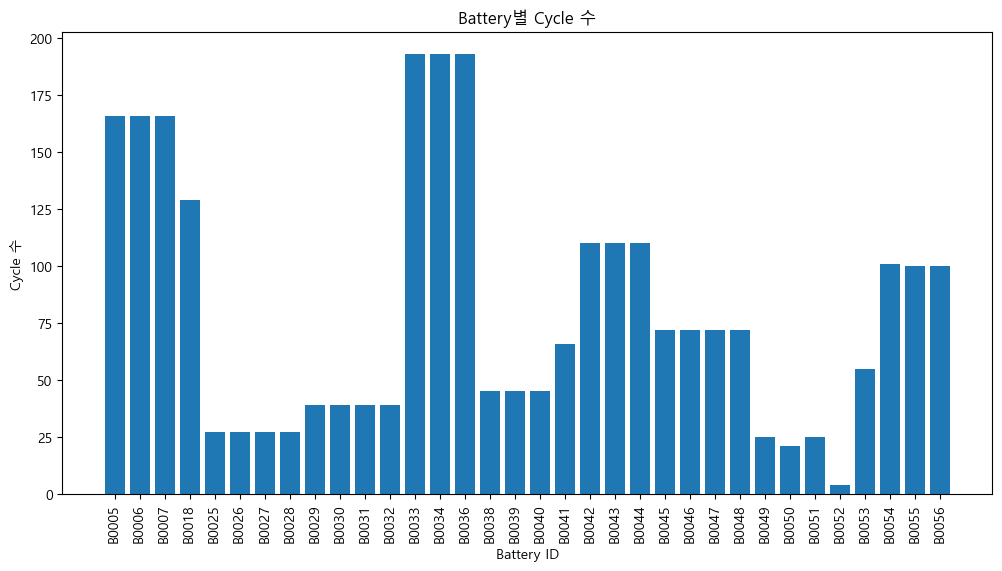

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(summary_df['battery_id'], summary_df['n_cycles'])

plt.xticks(rotation=90)
plt.title("Battery별 Cycle 수")
plt.xlabel("Battery ID")
plt.ylabel("Cycle 수")

plt.show()